In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Flight parameters

T = 10          # total cycle time (s)

u_f = 2.0       # upward velocity during flapping (m/s)
u_g = 1.0       # downward velocity during gliding (m/s)

h0 = 100        # initial altitude (m)


# Bird parameters

# Bird parameters

Ab = 0.01
Aw = 0.02
B = 0.01

m = 0.1
g = 9.81

In [19]:
x = u_g / (u_f + u_g)

print("Flapping fraction:", x)
print("Gliding fraction:", 1 - x)

Flapping fraction: 0.3333333333333333
Gliding fraction: 0.6666666666666667


In [4]:
t_f = x * T
t_g = (1 - x) * T

print("Flapping time:", t_f, "s")
print("Gliding time:", t_g, "s")

Flapping time: 3.333333333333333 s
Gliding time: 6.666666666666668 s


In [5]:
t = np.linspace(0, T, 1000)

In [6]:
h_peak = h0 + u_f * t_f

h = np.where(
    t <= t_f,
    h0 + u_f * t,
    h_peak - u_g * (t - t_f)
)

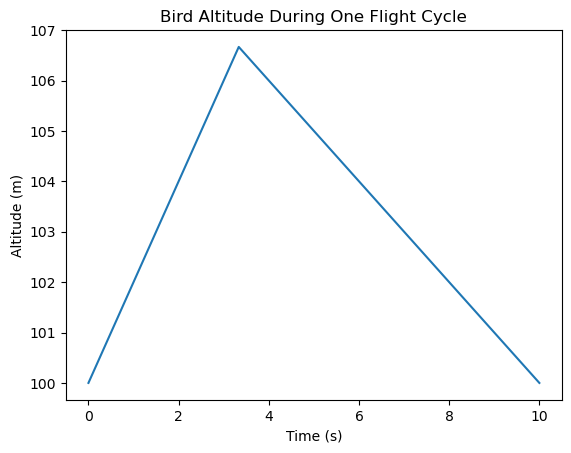

In [7]:
plt.plot(t, h)

plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.title("Bird Altitude During One Flight Cycle")

plt.show()

In [8]:
print("Initial altitude:", h[0])
print("Peak altitude:", np.max(h))
print("Final altitude:", h[-1])

Initial altitude: 100.0
Peak altitude: 106.66666666666667
Final altitude: 100.0


In [9]:
average_altitude = np.mean(h)

print("Average altitude:", average_altitude, "m")

Average altitude: 103.33 m


In [10]:
required_average_altitude = 100

altitude_offset = required_average_altitude - average_altitude

h_adjusted = h + altitude_offset

print("New average altitude:", np.mean(h_adjusted))

New average altitude: 100.0


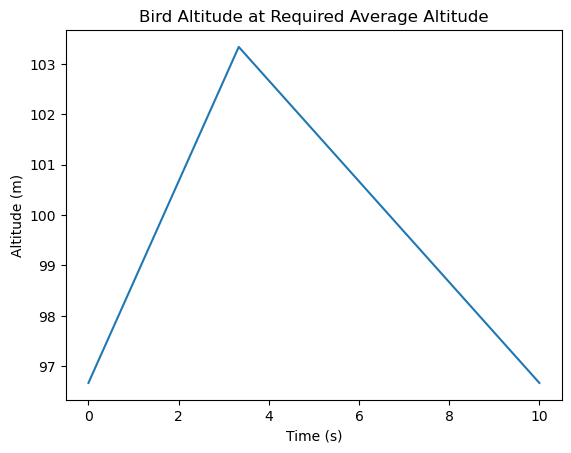

In [11]:
plt.plot(t, h_adjusted)

plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.title("Bird Altitude at Required Average Altitude")

plt.show()

In [12]:
required_average_altitude = 100

delta_h = u_f * t_f

h0 = required_average_altitude - delta_h / 2
h_peak = required_average_altitude + delta_h / 2

print("Initial altitude:", h0)
print("Peak altitude:", h_peak)

Initial altitude: 96.66666666666667
Peak altitude: 103.33333333333333


In [15]:
h = np.where(
    t <= t_f,
    h0 + u_f * t,
    h_peak - u_g * (t - t_f)
)

print("Average altitude:", np.mean(h))

Average altitude: 99.99666666666667


In [16]:
delta_h = 5  # altitude change per cycle (m)

h0 = required_average_altitude - delta_h / 2
h_peak = required_average_altitude + delta_h / 2

print("Altitude change:", delta_h, "m")
print("Initial altitude:", h0, "m")
print("Peak altitude:", h_peak, "m")

Altitude change: 5 m
Initial altitude: 97.5 m
Peak altitude: 102.5 m


In [22]:
potential_energy = m * g * delta_h

print("Potential energy gained:", potential_energy, "J")

Potential energy gained: 4.905 J


In [25]:
recovery_efficiency = 0.0

In [26]:
E_recovered = recovery_efficiency * E_up

print("Recovered energy during gliding:", E_recovered, "J")

Recovered energy during gliding: 0.0 J


In [27]:
E_altitude = E_up - E_recovered

print("Net altitude-related energy:", E_altitude, "J")

Net altitude-related energy: 4.905 J


In [29]:
v = 10  # horizontal speed (m/s)

distance_cycle = v * T

print("Distance traveled per cycle:", distance_cycle, "m")

Distance traveled per cycle: 100 m


In [1]:
def energy(x, v):
    return average_power(x, v) / v

In [3]:
def average_power(x, v):
    return Ab*v**3 + x*Aw*v**3 + (B*m**2*g**2)/(x*v)

In [4]:
def average_power(x, v):
    return Ab*v**3 + x*Aw*v**3 + (B*m**2*g**2)/(x*v)

In [7]:
x = 1/3
v = 10

E_paper = energy(x, v)

print("Paper energy per distance:", E_paper, "J/m")

Paper energy per distance: 1.6669553749666666 J/m


In [8]:
distance_cycle = v * T

print("Distance traveled per cycle:", distance_cycle, "m")

Distance traveled per cycle: 100 m


In [17]:
delta_h = 5
recovery_efficiency = 0.5
E_up = m * g * delta_h

E_recovered = recovery_efficiency * E_up

E_altitude = E_up - E_recovered

print("Altitude energy:", E_altitude, "J")

Altitude energy: 2.4525 J


In [18]:
distance_cycle = v * T

E_altitude_per_distance = E_altitude / distance_cycle

print("Altitude energy per distance:",
      E_altitude_per_distance, "J/m")

Altitude energy per distance: 0.024525 J/m


In [19]:
E_total = E_paper + E_altitude_per_distance

print("Total energy per distance:",
      E_total, "J/m")

Total energy per distance: 1.6914803749666665 J/m


In [20]:
delta_h_values = [1, 5, 10, 20]

for delta_h in delta_h_values:
    E_up = m * g * delta_h
    E_recovered = recovery_efficiency * E_up
    E_altitude = E_up - E_recovered
    
    E_altitude_per_distance = E_altitude / distance_cycle
    E_total = E_paper + E_altitude_per_distance
    
    print("Delta h:", delta_h, "m")
    print("Total energy per distance:", E_total, "J/m")
    print()

Delta h: 1 m
Total energy per distance: 1.6718603749666665 J/m

Delta h: 5 m
Total energy per distance: 1.6914803749666665 J/m

Delta h: 10 m
Total energy per distance: 1.7160053749666666 J/m

Delta h: 20 m
Total energy per distance: 1.7650553749666666 J/m



E_altitude ∝ Δh

For a fixed speed, flapping ratio, cycle duration, and recovery efficiency, larger altitude oscillations increase the energy required per unit distance.